In [1]:
image_set = "utzap"
text_set = "opencharacter"

In [2]:
from sklearn.metrics.pairwise import cosine_similarity
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import os
import numpy as np
import pickle
import json
import matplotlib.pyplot as plt
import openai
from tqdm.notebook import tqdm
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from tqdm_joblib import tqdm_joblib
from itertools import batched

In [3]:
with open(f"../generate_test_set/{image_set + "+" + text_set}/test_indices.json", "r") as f:
    test_indices = json.load(f)

In [4]:
embedding_mode = "clip"

In [5]:
with open(f'../data_preparation/{image_set}/images_test.pkl', 'rb') as f:
    sampled_images = pickle.load(f)
with open(f'../data_preparation/{text_set}/test_personas.json', 'r') as f:
    test_personas = json.load(f)[:len(test_indices)]

In [6]:
def search_description_embeddings_openaitext(text, embeddings, image_names, model, processor):

    response = openai.embeddings.create(
        input=text,
        model="text-embedding-ada-002"
    )

    text_features = [item.embedding for item in response.data]

    description_embeddings_tensor = torch.cat([torch.tensor(e) for e in embeddings])

    cos_sim = cosine_similarity(description_embeddings_tensor, text_features)

    D = {name: sim for name, sim in zip(image_names, cos_sim)}
    D = dict(sorted(D.items(), key=lambda item: item[1], reverse=True))
    return D

In [7]:
import tempfile
import os
from vertexai.generative_models import GenerativeModel
from vertexai.generative_models import Image as VertexImage
import re

def generate_caption(pil_image) -> list:

    model = GenerativeModel("gemini-2.0-flash")


    from google.api_core.exceptions import InternalServerError
    import time
    def safe_generate(prompt, image_obj, retries=5, delay=3):
        for attempt in range(retries):
            try:
                return model.generate_content([prompt]+[image_obj], generation_config={"temperature": 0.0})
            except InternalServerError as e:
                print(f"[Retry {attempt+1}/{retries}] Gemini 500 error: {e}")
                time.sleep(delay * (2 ** attempt))  # exponential backoff
            except Exception as e:
                print(f"[Retry {attempt+1}/{retries}] Unexpected error: {e}")
                time.sleep(delay * (2 ** attempt))  # exponential backoff

        return 0 #None


    prompt = f"""
    Generate a very detailed caption for the following images.
    Do NOT include any explanation or additional text.
    """
    try:
        # Save all images to temporary files, load into Image objects
        temp_files = []
        try:
            tmp = tempfile.NamedTemporaryFile(suffix=".png", delete=False)
            pil_image.save(tmp.name)
            temp_files.append(tmp.name)
            image_obj = VertexImage.load_from_file(tmp.name)
            tmp.close()

            # Generate response with prompt + all images
            response = safe_generate(prompt, image_obj)

            # You might get a single combined response — if you want per image,
            # you could send one call per image in a loop instead.

        finally:
            # Clean up temp files
            for f in temp_files:
                try:
                    os.remove(f)
                except Exception:
                    pass

        return response.text
    except Exception as e:
        print(f"Error generating response: {e}")
        return 0 #"Error generating response"

In [8]:
generate_caption(sampled_images[0])

'Beige suede wedge sandal with a peep toe, featuring a gathered and knotted vamp, a slingback strap with elasticized section, a jute-wrapped wedge heel, and a textured rubber outsole.\n'

In [9]:
if not os.path.exists(f"description_embeddings_{image_set}.pkl"):
    n_jobs = 8
    with tqdm_joblib(tqdm(desc="Generating captions", total=len(sampled_images))):
        image_descriptions = Parallel(n_jobs=n_jobs)(
            delayed(generate_caption)(img) for img in sampled_images
        )
    with open(f"image_descriptions_{image_set}.pkl", "wb") as f:
        pickle.dump(image_descriptions, f)

Generating captions:   0%|          | 0/4096 [00:00<?, ?it/s]

  0%|          | 0/4096 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [3]:
from dotenv import load_dotenv

load_dotenv()
openai.api_key = os.getenv("OPENAI_API_KEY")

In [ ]:
with open(f"image_descriptions_{image_set}.pkl", "rb") as f:
    image_descriptions = pickle.load(f)

In [ ]:
def embed_descriptions_openaitext(text_list):

    description_embeddings = []

    for text in text_list:

        response = openai.embeddings.create(
            input=text,
            model="text-embedding-ada-002"
        )

        raw_features = [item.embedding for item in response.data]

        description_features = raw_features / np.linalg.norm(raw_features)
        description_embeddings.append(description_features)
    return description_embeddings

In [ ]:
if not os.path.exists(f"description_embeddings_{image_set}.pkl"):

    for i, t in tqdm(enumerate(image_descriptions)):
        if not isinstance(t, str):
            image_descriptions[i] = generate_caption(sampled_images[i])

    description_embeddings = []
    for batch in tqdm(batched(image_descriptions, 1)):
        description_embeddings_batch = embed_descriptions_openaitext(batch)
        description_embeddings.extend(description_embeddings_batch)

In [ ]:
if not os.path.exists(f"persona_embeddings_{text_set}.pkl"):
    persona_embeddings = embed_descriptions_openaitext(test_personas)

In [ ]:
if not os.path.exists(f"persona_embeddings_{text_set}.pkl"):
    with open(f"persona_embeddings_{text_set}.pkl", "wb") as f:
        torch.save(persona_embeddings, f)
if not os.path.exists(f"description_embeddings_{image_set}.pkl"):
    with open(f"description_embeddings_{image_set}.pkl", "wb") as f:
        torch.save(description_embeddings, f)

In [ ]:
with open(f"persona_embeddings_{text_set}.pkl", "rb") as f:
    persona_embeddings = torch.load(f, weights_only=False) 
with open(f"description_embeddings_{image_set}.pkl", "rb") as f:
    description_embeddings = torch.load(f, weights_only=False)

In [ ]:
description_embeddings_tensor = torch.tensor(description_embeddings).squeeze()
persona_embeddings_tensor = torch.tensor(persona_embeddings)

In [ ]:
rank_list = []
sorted_indices_list = []

for i in range(len(persona_embeddings)):
    scores = cosine_similarity(
        description_embeddings_tensor.detach().cpu().numpy(),
        persona_embeddings_tensor[i].detach().cpu().numpy()
    )
    sorted_indices = np.argsort(scores, axis=0)[::-1].squeeze()
    sorted_indices_list.append(sorted_indices)
    n = sorted_indices.tolist().index(test_indices[i])
    rank_list.append(n)

In [ ]:
from tqdm.notebook import tqdm

top_5 = 0
top_20 = 0
top_100 = 0
top_500 = 0

for i in tqdm(range(len(rank_list))):
    if rank_list[i] < 5:
        top_5 += 1/len(rank_list)
    if rank_list[i] < 20:
        top_20 += 1/len(rank_list)
    if rank_list[i] < 100:
        top_100 += 1/len(rank_list)
    if rank_list[i] < 500:
        top_500 += 1/len(rank_list)

  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
print("Top 5:", top_5, "Top 20:", top_20, "Top 100:", top_100, "Top 500:", top_500)
print(1-np.median(rank_list)/len(description_embeddings_tensor))
print(1-np.mean(rank_list)/len(description_embeddings_tensor))

Top 5: 0.02 Top 20: 0.04 Top 100: 0.1 Top 500: 0.25999999999999995
0.743408203125
0.6732666015625


Carmen, a 46-year-old air traffic control specialist, balances her high-stress job with creative outlets like painting and yoga, while her competitive nature and love for history shape her worldview


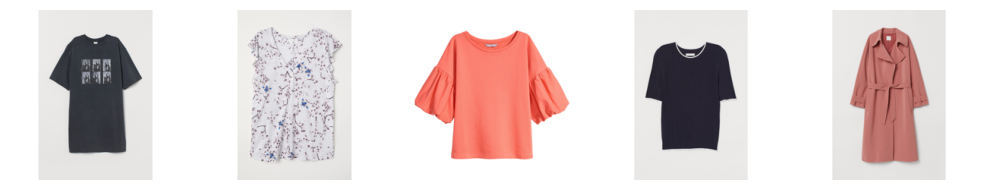

In [ ]:
n = 1
print(test_personas[n])
img_list = [sampled_images[k] for k in sorted_indices_list[n]]

num_images = 5
cols = 10  # images per row
rows = int(np.ceil(num_images / cols))

plt.figure(figsize=(cols * 2, rows * 2))  # adjust size as needed

for i in range(num_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img_list[i])
    plt.axis("off")

plt.tight_layout()
plt.show()